# Gamma Trading - Example from Derman's Chapter 3

## The Volatility Smile - Emanuel Derman, Michael B. Miller, David Park

This notebook replicates the **gamma trading** example presented in Chapter 3 of the book.

### Key Concepts:
- **Delta hedging**: Neutralizing sensitivity to underlying price movements
- **Gamma**: The sensitivity of delta to underlying price movements  
- **Gamma trading P&L**: Depends on the difference between realized and implied volatility
- **Long gamma** (long options): Profit when realized vol > implied vol
- **Short gamma** (short options): Profit when realized vol < implied vol


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Black-Scholes: Greeks Formulas

Implement Black-Scholes formulas to calculate option prices and Greeks needed for delta hedging.


In [2]:
def black_scholes_call(S, K, T, r, sigma):
    """Calculate European call price using Black-Scholes"""
    if T <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def delta_call(S, K, T, r, sigma):
    """Calculate delta of a European call"""
    if T <= 0:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def gamma(S, K, T, r, sigma):
    """Calculate gamma (same for call and put)"""
    if T <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def theta_call(S, K, T, r, sigma):
    """Calculate theta of a European call (per day)"""
    if T <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) 
             - r * K * np.exp(-r * T) * norm.cdf(d2))
    return theta / 365  # Convert to daily theta


## 2. Underlying Price Simulation

Simulate a path of the underlying using a Geometric Brownian Motion with a specific **realized volatility**.


In [3]:
def simulate_gbm(S0, mu, sigma_realized, T, n_steps, seed=42):
    """
    Simulate a Geometric Brownian Motion
    
    Parameters:
    S0: Initial price
    mu: Drift (expected return rate)
    sigma_realized: Realized volatility
    T: Total time (years)
    n_steps: Number of time steps
    seed: Random seed for reproducibility
    
    Returns:
    prices: Array of simulated prices
    times: Array of times
    """
    np.random.seed(seed)
    dt = T / n_steps
    times = np.linspace(0, T, n_steps + 1)
    dW = np.random.normal(0, np.sqrt(dt), n_steps)
    
    prices = np.zeros(n_steps + 1)
    prices[0] = S0
    
    for i in range(n_steps):
        prices[i + 1] = prices[i] * np.exp((mu - 0.5 * sigma_realized**2) * dt + sigma_realized * dW[i])
    
    return prices, times


## 3. Gamma Trading Strategy with Delta Hedging

Implement the strategy described in Chapter 3:
1. Buy an ATM call option (long gamma)
2. Delta hedge the position by selling the underlying
3. Rehedge periodically (discrete rebalancing)
4. Track total P&L


In [4]:
def gamma_trading_simulation(S0, K, T, r, sigma_implied, sigma_realized, 
                            n_steps, rehedge_frequency=1, seed=42):
    """
    Simulate a gamma trading strategy with delta hedging
    
    Parameters:
    S0: Initial underlying price
    K: Strike price
    T: Option maturity (years)
    r: Risk-free rate
    sigma_implied: Implied volatility used for option pricing
    sigma_realized: Realized volatility of the underlying
    n_steps: Total number of time steps
    rehedge_frequency: Rehedge every N steps (1 = every step)
    seed: Random seed
    
    Returns:
    DataFrame with simulation results
    """
    # Simulate underlying path
    prices, times = simulate_gbm(S0, r, sigma_realized, T, n_steps, seed)
    
    results = []
    
    # Initial option price
    initial_option_price = black_scholes_call(S0, K, T, r, sigma_implied)
    
    # Initial setup
    delta_hedge = 0  # Position in underlying (number of shares)
    cash = -initial_option_price  # Cash account (we pay for the option)
    
    for i in range(n_steps + 1):
        S = prices[i]
        t = times[i]
        time_to_maturity = T - t
        
        # Calculate current option value and Greeks
        if time_to_maturity > 0:
            option_value = black_scholes_call(S, K, time_to_maturity, r, sigma_implied)
            delta_option = delta_call(S, K, time_to_maturity, r, sigma_implied)
            gamma_option = gamma(S, K, time_to_maturity, r, sigma_implied)
            theta_option = theta_call(S, K, time_to_maturity, r, sigma_implied)
        else:
            option_value = max(S - K, 0)
            delta_option = 1.0 if S > K else 0.0
            gamma_option = 0.0
            theta_option = 0.0
        
        # Rehedging
        if i % rehedge_frequency == 0 and i < n_steps:
            delta_target = -delta_option  # Sell underlying to neutralize
            delta_change = delta_target - delta_hedge
            cash -= delta_change * S  # Sell (negative) or buy (positive)
            delta_hedge = delta_target
        
        # Calculate total P&L
        portfolio_value = option_value + delta_hedge * S + cash
        
        results.append({
            'Time': t,
            'Days': t * 365,
            'Stock_Price': S,
            'Time_to_Maturity': time_to_maturity,
            'Option_Value': option_value,
            'Delta': delta_option,
            'Gamma': gamma_option,
            'Theta': theta_option,
            'Hedge_Position': delta_hedge,
            'Cash': cash,
            'Portfolio_Value': portfolio_value,
            'PnL': portfolio_value
        })
    
    return pd.DataFrame(results)


## 4. Base Scenario Example (as in Derman's book)

Replicate the Chapter 3 example with the following parameters:
- Stock ATM: $S_0 = K = 100$
- Maturity: 1 month (T = 1/12 years)
- Risk-free rate: 5%
- Implied volatility: 20%
- Realized volatility: 30% (higher than implied)
- Rehedging: Daily


In [5]:
# Example parameters
S0 = 100.0          # Initial price
K = 100.0           # ATM strike
T = 1/12            # 1 month
r = 0.05            # 5% risk-free rate
sigma_implied = 0.20   # 20% implied volatility
sigma_realized = 0.30  # 30% realized volatility
n_steps = 21        # ~21 trading days in a month
rehedge_freq = 1    # Daily rehedging

# Run simulation
df = gamma_trading_simulation(S0, K, T, r, sigma_implied, sigma_realized, 
                              n_steps, rehedge_frequency=rehedge_freq, seed=42)

# Show results
print("="*80)
print("GAMMA TRADING SIMULATION - Base Scenario")
print("="*80)
print(f"Implied Volatility: {sigma_implied*100:.1f}%")
print(f"Realized Volatility: {sigma_realized*100:.1f}%")
print(f"Difference: {(sigma_realized - sigma_implied)*100:.1f}%")
print(f"\nInitial option price: ${df.iloc[0]['Option_Value']:.4f}")
print(f"Final P&L: ${df.iloc[-1]['PnL']:.4f}")
print("="*80)

# Display table
display_cols = ['Days', 'Stock_Price', 'Option_Value', 'Delta', 'Gamma', 
                'Hedge_Position', 'PnL']
print("\nFirst and last rows of simulation:")
print(df[display_cols].head(10))
print("...")
print(df[display_cols].tail(5))


GAMMA TRADING SIMULATION - Base Scenario
Implied Volatility: 20.0%
Realized Volatility: 30.0%
Difference: 10.0%

Initial option price: $2.5121
Final P&L: $0.6490

First and last rows of simulation:
        Days  Stock_Price  Option_Value     Delta     Gamma  Hedge_Position  \
0   0.000000   100.000000      2.512067  0.540239  0.068747       -0.540239   
1   1.448413   100.945124      2.987424  0.604710  0.067712       -0.604710   
2   2.896825   100.683701      2.764556  0.587134  0.070423       -0.587134   
3   4.345238   101.925682      3.479961  0.673781  0.066163       -0.673781   
4   5.793651   104.904073      5.694665  0.844363  0.043846       -0.844363   
5   7.242063   104.442961      5.252470  0.829145  0.048232       -0.829145   
6   8.690476   103.983909      4.816060  0.812193  0.053101       -0.812193   
7  10.138889   107.136136      7.549554  0.938794  0.023957       -0.938794   
8  11.587302   108.703427      9.014139  0.972358  0.012873       -0.972358   
9  13.035714

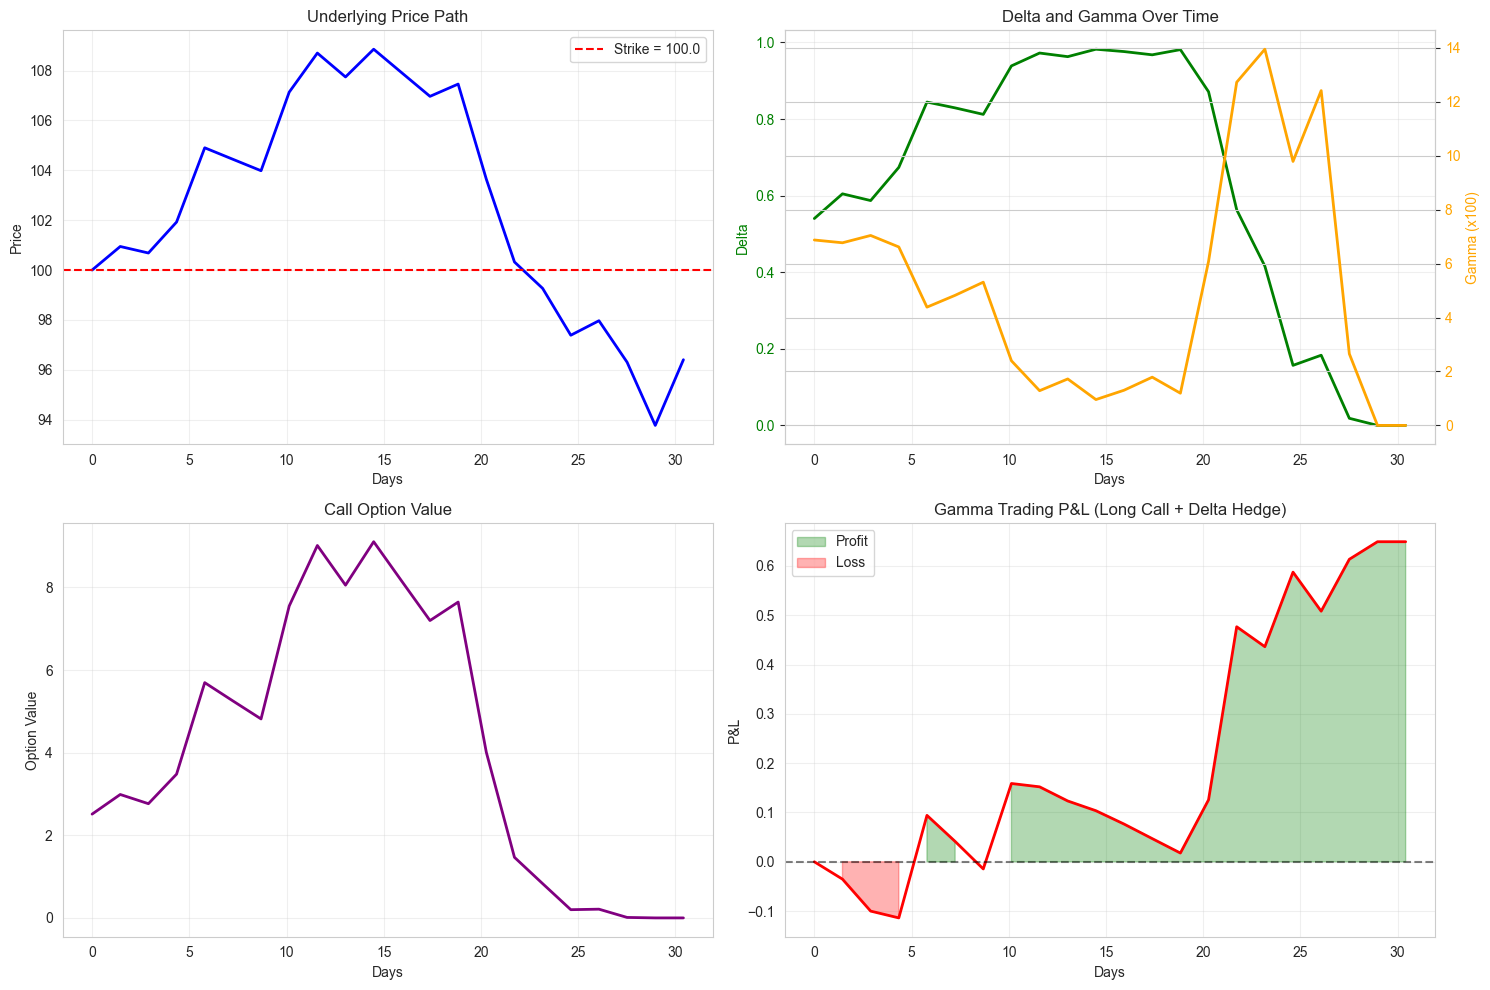

In [6]:
# Create main visualization: P&L Components
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Underlying price
axes[0, 0].plot(df['Days'], df['Stock_Price'], 'b-', linewidth=2)
axes[0, 0].axhline(y=K, color='r', linestyle='--', label=f'Strike = {K}')
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('Price')
axes[0, 0].set_title('Underlying Price Path')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Delta and Gamma
ax2 = axes[0, 1]
ax2.plot(df['Days'], df['Delta'], 'g-', linewidth=2, label='Delta')
ax2.set_xlabel('Days')
ax2.set_ylabel('Delta', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.set_title('Delta and Gamma Over Time')
ax2.grid(True, alpha=0.3)

ax2_twin = ax2.twinx()
ax2_twin.plot(df['Days'], df['Gamma']*100, 'orange', linewidth=2, label='Gamma (x100)')
ax2_twin.set_ylabel('Gamma (x100)', color='orange')
ax2_twin.tick_params(axis='y', labelcolor='orange')

# 3. Option value
axes[1, 0].plot(df['Days'], df['Option_Value'], 'purple', linewidth=2)
axes[1, 0].set_xlabel('Days')
axes[1, 0].set_ylabel('Option Value')
axes[1, 0].set_title('Call Option Value')
axes[1, 0].grid(True, alpha=0.3)

# 4. Cumulative P&L
axes[1, 1].plot(df['Days'], df['PnL'], 'r-', linewidth=2)
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Days')
axes[1, 1].set_ylabel('P&L')
axes[1, 1].set_title('Gamma Trading P&L (Long Call + Delta Hedge)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].fill_between(df['Days'], 0, df['PnL'], where=(df['PnL'] >= 0), 
                        alpha=0.3, color='green', label='Profit')
axes[1, 1].fill_between(df['Days'], 0, df['PnL'], where=(df['PnL'] < 0), 
                        alpha=0.3, color='red', label='Loss')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 5. Analysis: Realized vs Implied Volatility

The key point from Derman's Chapter 3 is that **gamma trading P&L depends on the difference between realized and implied volatility**.

Test this relationship with different scenarios:


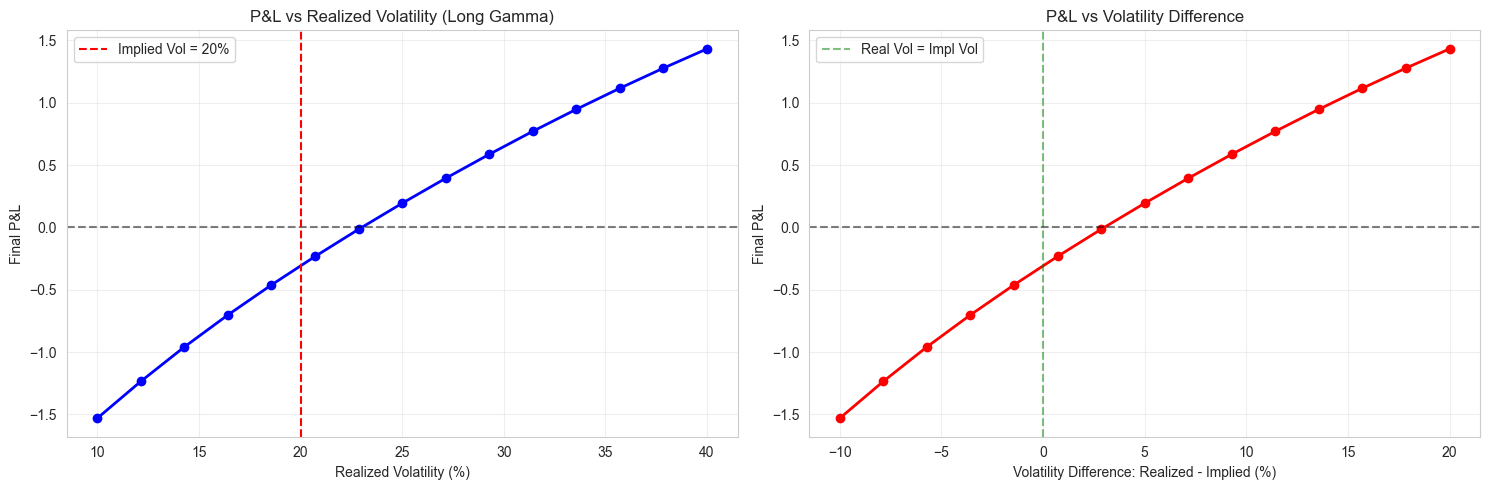


Comparison results:
 Realized_Vol  Implied_Vol   Vol_Diff  Final_PnL
    10.000000         20.0 -10.000000  -1.530169
    12.142857         20.0  -7.857143  -1.234455
    14.285714         20.0  -5.714286  -0.958264
    16.428571         20.0  -3.571429  -0.701464
    18.571429         20.0  -1.428571  -0.460702
    20.714286         20.0   0.714286  -0.232576
    22.857143         20.0   2.857143  -0.014783
    25.000000         20.0   5.000000   0.193963
    27.142857         20.0   7.142857   0.394324
    29.285714         20.0   9.285714   0.586633
    31.428571         20.0  11.428571   0.771059
    33.571429         20.0  13.571429   0.947702
    35.714286         20.0  15.714286   1.116662
    37.857143         20.0  17.857143   1.278092
    40.000000         20.0  20.000000   1.432225


In [7]:
# Test with different realized volatilities
sigma_impl = 0.20
sigma_real_values = np.linspace(0.10, 0.40, 15)

results_comparison = []

for sigma_real in sigma_real_values:
    df_temp = gamma_trading_simulation(S0, K, T, r, sigma_impl, sigma_real, 
                                       n_steps, rehedge_frequency=rehedge_freq, seed=42)
    final_pnl = df_temp.iloc[-1]['PnL']
    
    results_comparison.append({
        'Realized_Vol': sigma_real * 100,
        'Implied_Vol': sigma_impl * 100,
        'Vol_Diff': (sigma_real - sigma_impl) * 100,
        'Final_PnL': final_pnl
    })

df_comparison = pd.DataFrame(results_comparison)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: P&L vs Realized Vol
axes[0].plot(df_comparison['Realized_Vol'], df_comparison['Final_PnL'], 
             'bo-', linewidth=2, markersize=6)
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[0].axvline(x=sigma_impl*100, color='r', linestyle='--', 
                label=f'Implied Vol = {sigma_impl*100:.0f}%')
axes[0].set_xlabel('Realized Volatility (%)')
axes[0].set_ylabel('Final P&L')
axes[0].set_title('P&L vs Realized Volatility (Long Gamma)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: P&L vs Vol Difference
axes[1].plot(df_comparison['Vol_Diff'], df_comparison['Final_PnL'], 
             'ro-', linewidth=2, markersize=6)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1].axvline(x=0, color='g', linestyle='--', alpha=0.5, label='Real Vol = Impl Vol')
axes[1].set_xlabel('Volatility Difference: Realized - Implied (%)')
axes[1].set_ylabel('Final P&L')
axes[1].set_title('P&L vs Volatility Difference')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nComparison results:")
print(df_comparison.to_string(index=False))


## 6. Gamma vs Theta Trade-off

### The Fundamental Trade-off

When you're **long a call option** and **delta hedging**:
- **Long Gamma**: Benefit from market movements (profit from rehedging)
- **Short Theta**: Pay time decay every day

**Key question**: How much does the underlying need to move daily to offset theta?

### Daily Break-Even Move

The gamma P&L for a move ΔS is:
$$ \text{Gamma P\&L} \approx \frac{1}{2} \Gamma (\Delta S)^2 $$

The daily theta decay is:
$$\text{Theta Decay} = \Theta \times dt$$

Break-even when Gamma P&L = |Theta decay|:
$$\Delta S_{\text{break-even}} = \sqrt{\frac{2 |\Theta| \times dt}{\Gamma}}$$


In [8]:
def calculate_breakeven_move(S, K, T, r, sigma):
    """Calculate daily break-even move needed to offset theta decay"""
    if T <= 0:
        return 0.0, 0.0, 0.0, 0.0
    
    gamma_val = gamma(S, K, T, r, sigma)
    theta_val = theta_call(S, K, T, r, sigma)
    
    if gamma_val <= 0:
        return 0.0, 0.0, gamma_val, theta_val
    
    breakeven_move = np.sqrt(2 * abs(theta_val) / gamma_val)
    breakeven_move_pct = (breakeven_move / S) * 100
    
    return breakeven_move, breakeven_move_pct, gamma_val, theta_val

# Test with different maturities
S = 100.0
r = 0.05
sigma = 0.20

print("="*100)
print("DAILY BREAK-EVEN MOVE - ATM Options with Different Maturities")
print("="*100)
print(f"{'Maturity':<15} {'Gamma':<12} {'Theta/day':<12} {'BE Move $':<12} {'BE Move %':<12} {'Daily Vol %':<12}")
print("-"*100)

maturities_days = [7, 14, 21, 30, 60, 90, 180, 365]
results_maturity = []

for days in maturities_days:
    T_mat = days / 365
    K = S  # ATM
    be_move, be_move_pct, gamma_val, theta_val = calculate_breakeven_move(S, K, T_mat, r, sigma)
    daily_vol_pct = (sigma / np.sqrt(252)) * 100
    
    results_maturity.append({
        'Days': days,
        'Maturity': T_mat,
        'Gamma': gamma_val,
        'Theta': theta_val,
        'BE_Move': be_move,
        'BE_Move_Pct': be_move_pct,
        'Daily_Vol_Impl': daily_vol_pct
    })
    
    print(f"{days:>3} days       {gamma_val:>10.6f}  {theta_val:>10.4f}  ${be_move:>10.4f}  {be_move_pct:>10.4f}%  {daily_vol_pct:>10.4f}%")

df_maturity = pd.DataFrame(results_maturity)
print("="*100)
print("\nNote: BE Move % is how much the underlying must move to offset daily theta")
print("      If daily move > BE Move, then Gamma P&L > |Theta| and you profit")


DAILY BREAK-EVEN MOVE - ATM Options with Different Maturities
Maturity        Gamma        Theta/day    BE Move $    BE Move %    Daily Vol % 
----------------------------------------------------------------------------------------------------
  7 days         0.143869     -0.0858  $    1.0921      1.0921%      1.2599%
 14 days         0.101611     -0.0627  $    1.1107      1.1107%      1.2599%
 21 days         0.082868     -0.0524  $    1.1249      1.1249%      1.2599%
 30 days         0.069228     -0.0450  $    1.1401      1.1401%      1.2599%
 60 days         0.048706     -0.0338  $    1.1783      1.1783%      1.2599%
 90 days         0.039568     -0.0288  $    1.2075      1.2075%      1.2599%
180 days         0.027560     -0.0223  $    1.2734      1.2734%      1.2599%
365 days         0.018762     -0.0176  $    1.3687      1.3687%      1.2599%

Note: BE Move % is how much the underlying must move to offset daily theta
      If daily move > BE Move, then Gamma P&L > |Theta| and you 

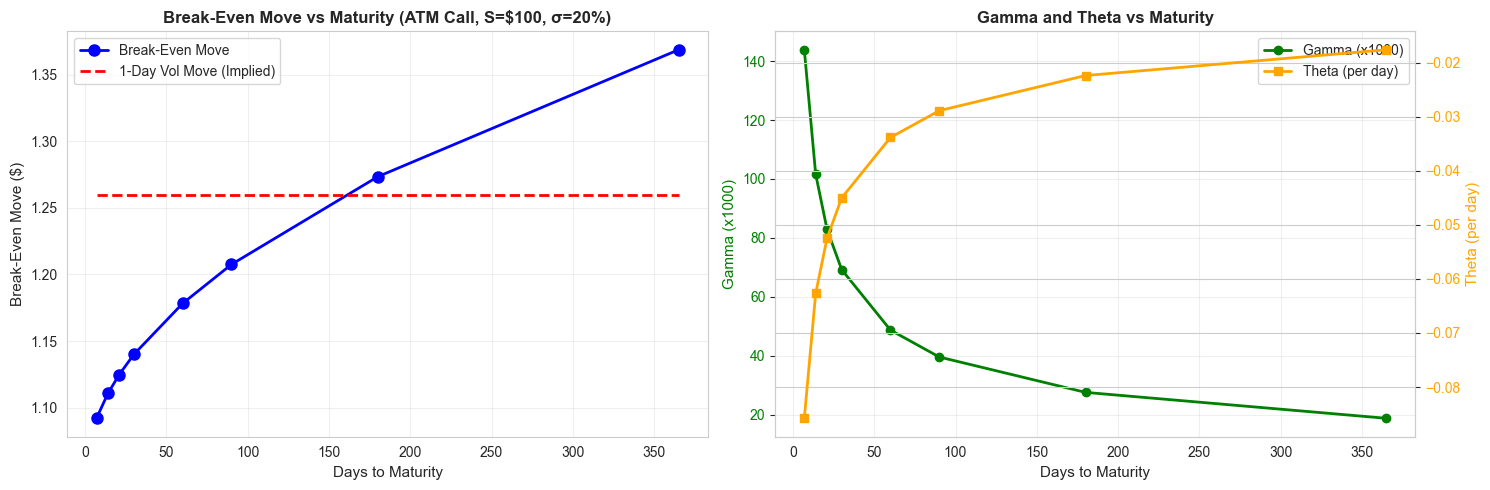

In [9]:
# Visualization: Break-Even Move vs Maturity
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Break-Even Move $ vs Maturity
axes[0].plot(df_maturity['Days'], df_maturity['BE_Move'], 'b-o', linewidth=2, markersize=8, label='Break-Even Move')
axes[0].plot(df_maturity['Days'], df_maturity['Daily_Vol_Impl'] * S / 100, 'r--', linewidth=2, label='1-Day Vol Move (Implied)')
axes[0].set_xlabel('Days to Maturity', fontsize=11)
axes[0].set_ylabel('Break-Even Move ($)', fontsize=11)
axes[0].set_title('Break-Even Move vs Maturity (ATM Call, S=$100, σ=20%)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Gamma and Theta vs Maturity
ax2 = axes[1]
ax2_twin = ax2.twinx()

line1 = ax2.plot(df_maturity['Days'], df_maturity['Gamma']*1000, 'g-', linewidth=2, marker='o', markersize=6, label='Gamma (x1000)')
ax2.set_xlabel('Days to Maturity', fontsize=11)
ax2.set_ylabel('Gamma (x1000)', color='g', fontsize=11)
ax2.tick_params(axis='y', labelcolor='g')

line2 = ax2_twin.plot(df_maturity['Days'], df_maturity['Theta'], 'orange', linewidth=2, marker='s', markersize=6, label='Theta (per day)')
ax2_twin.set_ylabel('Theta (per day)', color='orange', fontsize=11)
ax2_twin.tick_params(axis='y', labelcolor='orange')

ax2.set_title('Gamma and Theta vs Maturity', fontsize=12, fontweight='bold')
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Conclusions

This notebook replicated the gamma trading example from Derman's Chapter 3, demonstrating:

1. **Long Gamma is Long Realized Volatility**: When you buy an option and delta hedge, you profit if realized vol exceeds implied vol.

2. **P&L Depends on Variance Difference**: The approximate formula $\text{P\&L} \approx \frac{1}{2} \Gamma S^2 (\sigma_{\text{real}}^2 - \sigma_{\text{impl}}^2) T$ captures the essence of gamma trading.

3. **Rehedging Frequency**: More frequent rehedging brings results closer to Black-Scholes theory (continuous delta hedging).

4. **Theta vs Gamma Trade-off**: There's a fundamental trade-off:
   - **Theta (time decay)**: You pay every day
   - **Gamma P&L**: You earn from rehedging when the market moves

5. **Break-Even Move**: The daily move needed to offset theta is:
   $$\Delta S_{\text{BE}} = \sqrt{\frac{2|\Theta|}{\Gamma}}$$
   This is approximately equal to the daily implied volatility.

### Practical Applications:
- **Market makers**: Continuously manage gamma risk and calculate break-even moves
- **Volatility traders**: Seek to exploit discrepancies between implied and realized vol
- **Risk management**: Understanding gamma is fundamental for managing options portfolios
- **Trading decisions**: Break-even move helps decide whether to buy or sell options
